In [1]:
import os

from torchvision import transforms as T
import torchvision.transforms.functional as F
from torchvision.io import read_image

> Attention : utilisation d'un répertoire de données en dehors de l'environnement du notebook !

In [2]:
from datasets import DATASET_0, DATASET_2, get_title
from utils import display_rgb_distributions, UnNormalize

import utils
print(utils.__version__)

1.0.4


In [3]:
DataPath = DATASET_2["path"]
ImageFile = "n02128757_snow_leopard.JPEG"

Affichage d'une image

In [4]:
def display_image(img_tensor, verbose=True):
    if verbose:
        print("Dimensions", img_tensor.size(), "\nValeur min:", img_tensor.min().item(), "\nValeur max:", img_tensor.max().item())

    img1 = T.functional.to_pil_image(img_tensor)
    display(img1)

n02128757_snow_leopard
Dimensions torch.Size([3, 345, 500]) 
Valeur min: 0 
Valeur max: 255


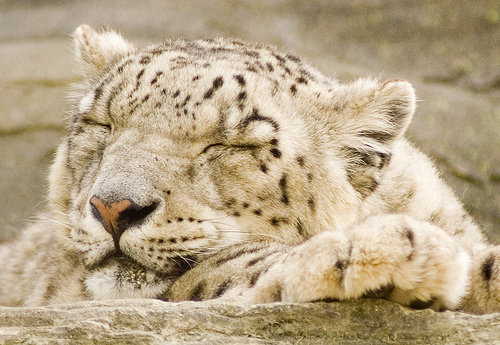

In [5]:
filename = os.path.join(DataPath, ImageFile)
img_tensor = read_image(filename) # Format : torch.Tensor

print(get_title(filename.split("/")[-1], DataPath))
display_image(img_tensor)

Affichage des distributions des canaux de couleurs

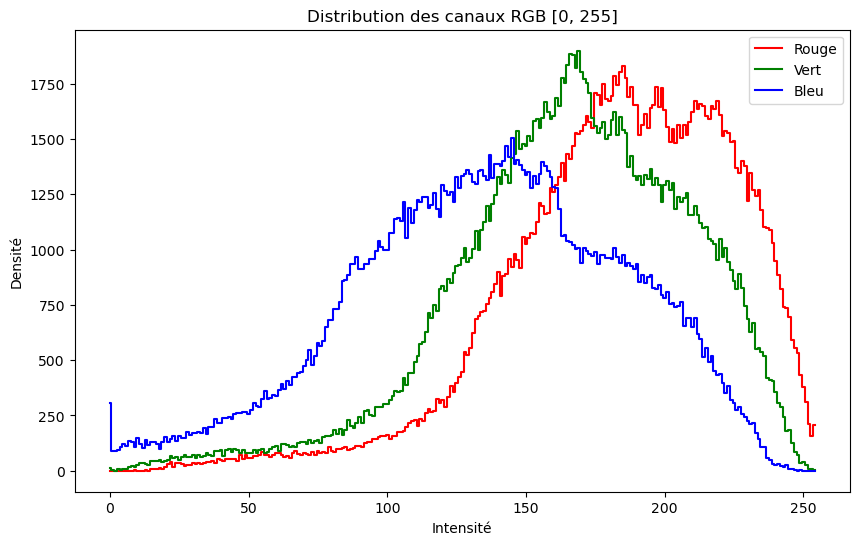

In [6]:
display_rgb_distributions(img_tensor.numpy().transpose(1, 2, 0), suf_title=" [0, 255]")

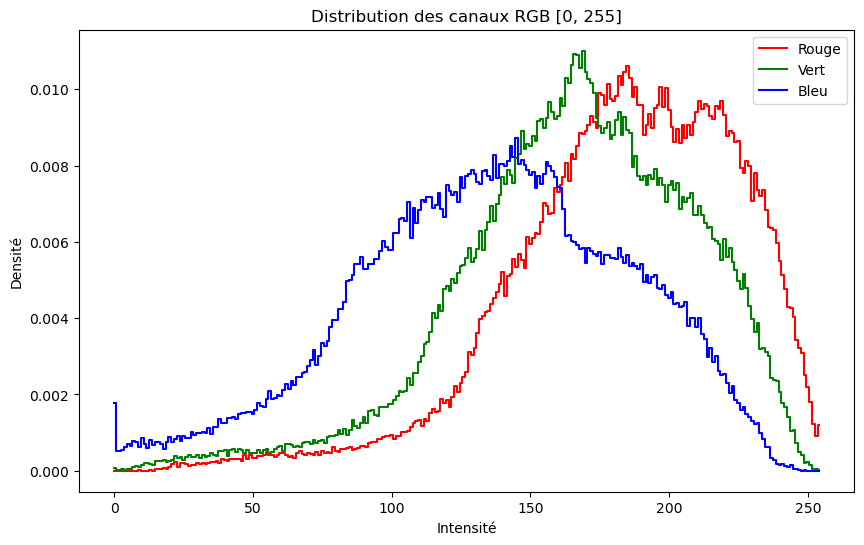

In [7]:
display_rgb_distributions(img_tensor.numpy().transpose(1, 2, 0), suf_title=" [0, 255]", density=True)

Application de transformations : simple normalisation

n02128757_snow_leopard
Dimensions torch.Size([3, 345, 500]) 
Valeur min: 0.0 
Valeur max: 1.0


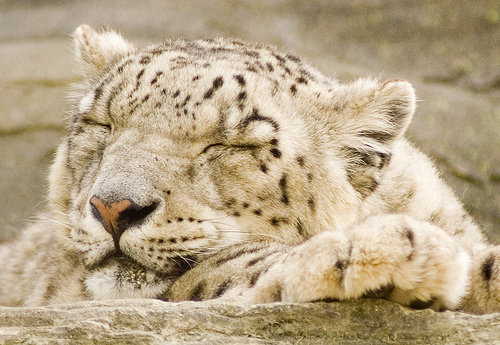

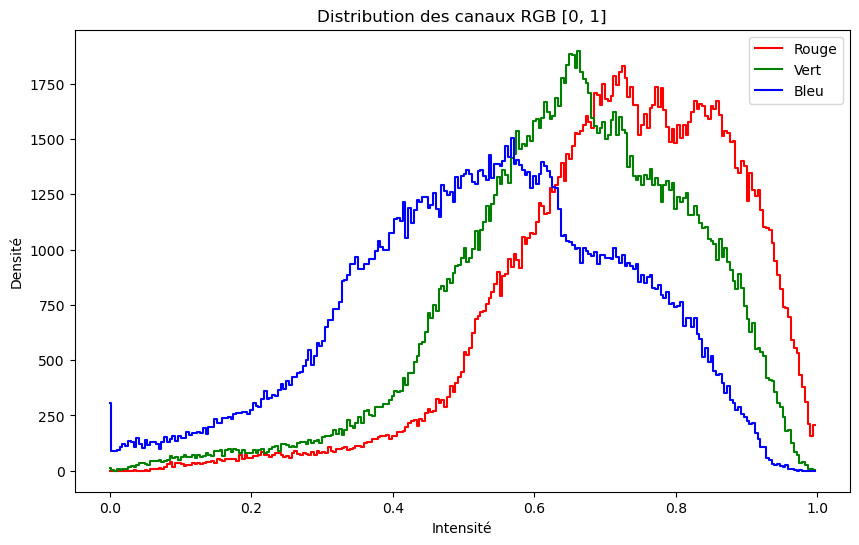

In [8]:
transforms0 = T.Compose([
    T.Lambda(lambda t: t/255.), # because read_image -> [0..255]
])

input0 = transforms0(img_tensor)
print(get_title(filename.split("/")[-1], DataPath))
display_image(input0)

display_rgb_distributions(input0.numpy().transpose(1, 2, 0), max_value=1., suf_title=" [0, 1]")

Applications de plusieurs transformations

n02128757_snow_leopard
Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.003921568859368563 
Valeur max: 1.0


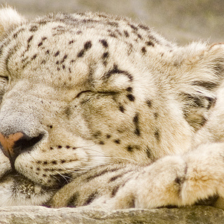

In [9]:
transforms0 = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.Lambda(lambda t: t/255.), # because read_image -> [0..255]
])

input0 = transforms0(img_tensor)
print(get_title(filename.split("/")[-1], DataPath))
display_image(input0)

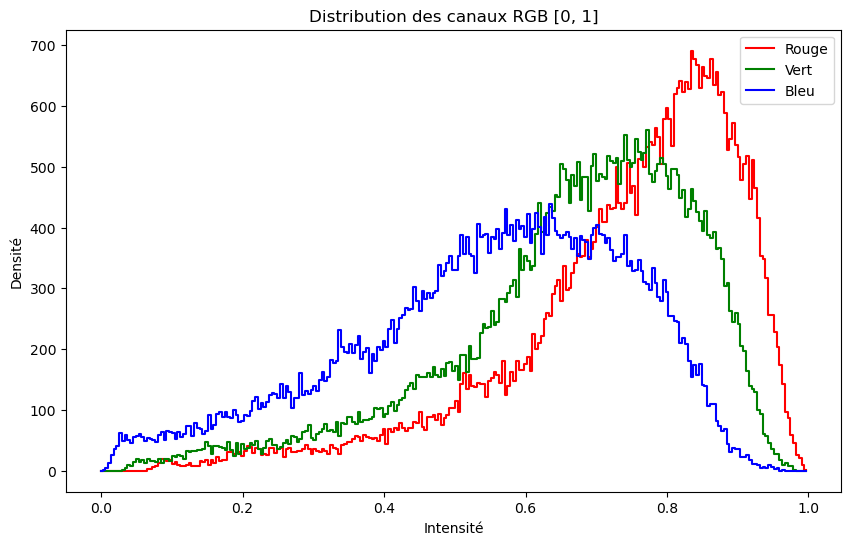

In [10]:
display_rgb_distributions(input0.numpy().transpose(1, 2, 0), max_value=1., suf_title=" [0, 1]")

Applications de transformation terminant par une normalisation basée sur les stats d'Imagenet

In [ ]:
imagenet_mean = DATASET_0["means"]
imagenet_std = DATASET_0["stds"]

transforms = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.Lambda(lambda t: t/255.), # because read_image -> [0..255]
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

n02128757_snow_leopard
Dimensions torch.Size([3, 224, 224]) 
Valeur min: -1.895658254623413 
Valeur max: 2.483137607574463


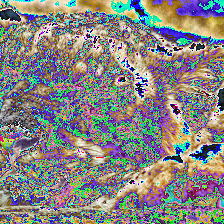

In [15]:
input = transforms(img_tensor)
print(get_title(filename.split("/")[-1], DataPath))
display_image(input)

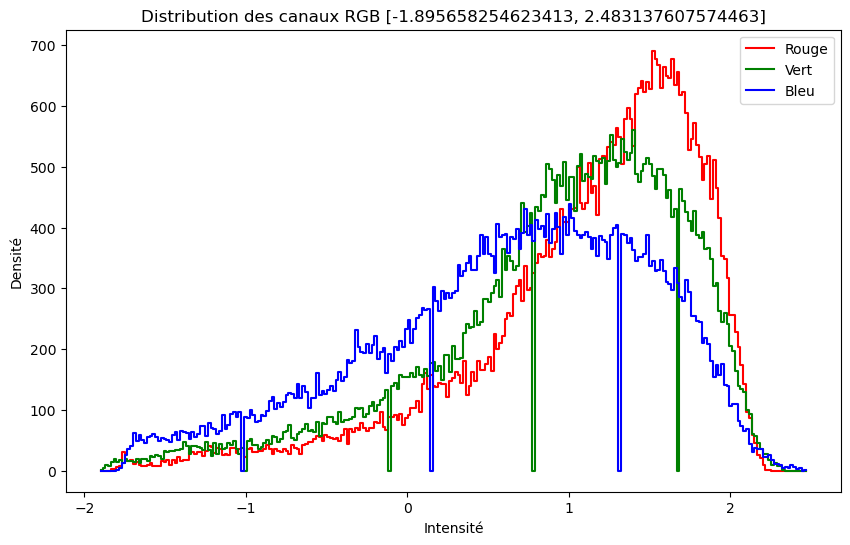

In [17]:
min_value=input.min().item()
max_value=input.max().item()
display_rgb_distributions(input.numpy().transpose(1, 2, 0),
                          min_value=min_value,
                          max_value=max_value,
                          suf_title= f" [{min_value}, {max_value}]")

Du fait de l'étirement de $[0 \ , 1]$ à $[-1,895658254623413 \ , 2,483137607574463]$, des creux apparaissent certainement en conséquence d'arrondis.

Application d'une ReLu puis afficher l'image

n02128757_snow_leopard
Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.0 
Valeur max: 2.483137607574463


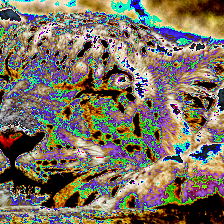

In [ ]:
input_relu = F.relu(input)
print(get_title(filename.split("/")[-1], DataPath))
display_image(input_relu)

En faisant en sorte d'exclure les $0$ obtenus avec le ReLU, et en se restraignant à 256/2 intervals.

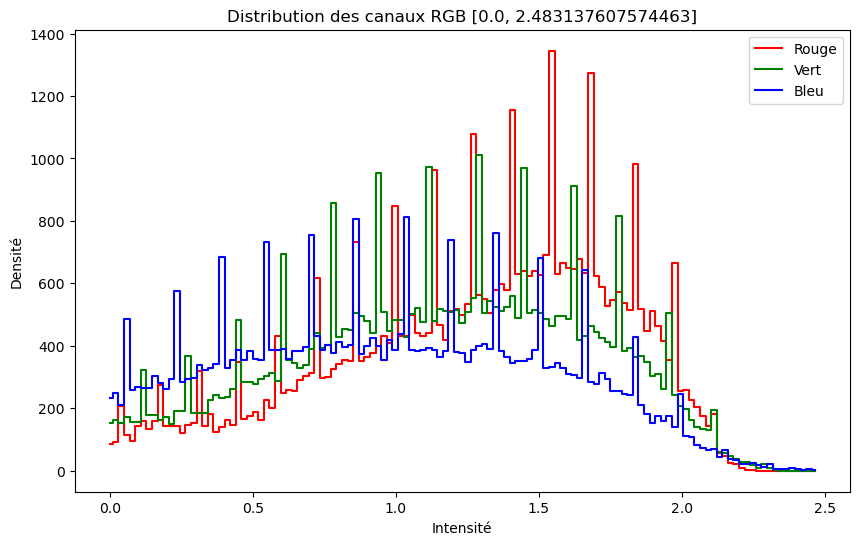

In [26]:
min_value=input_relu.min().item()
max_value=input_relu.max().item()
display_rgb_distributions(input_relu.numpy().transpose(1, 2, 0),
                          min_value=min_value+1e-10,
                          max_value=max_value,
                          bins=int(256/2),
                          suf_title= f" [{min_value}, {max_value}]")

En appliquant une dénormalisation (inverser la normalisation)

n02128757_snow_leopard
Dimensions torch.Size([3, 224, 224]) 
Valeur min: 0.003921577241271734 
Valeur max: 1.0


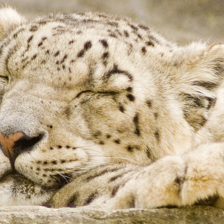

In [14]:
input_un = UnNormalize(imagenet_mean, imagenet_std)(input)
print(get_title(filename.split("/")[-1], DataPath))
display_image(input_un)

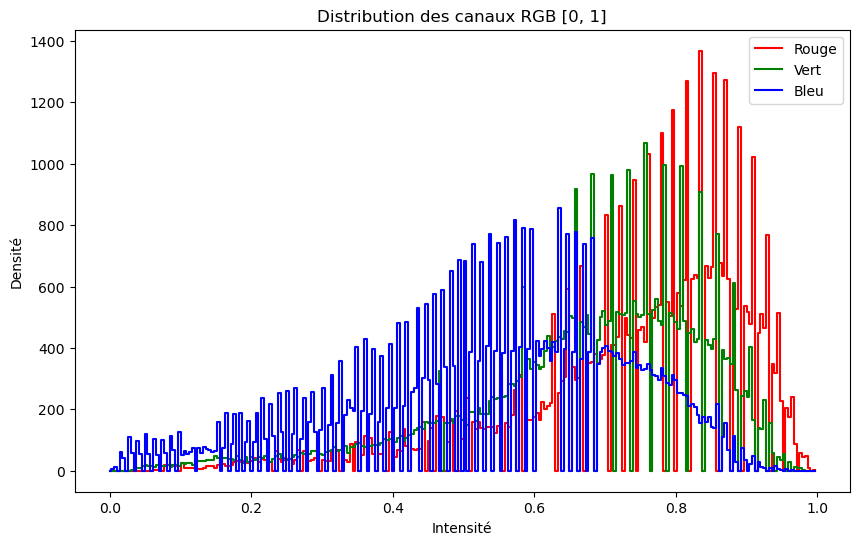

In [15]:
display_rgb_distributions(input_un.numpy().transpose(1, 2, 0), max_value=1., suf_title=" [0, 1]")

On constate les effets de bord des arrondis avec la normalisation-dénormalisation.